# Framing Divergence Indicators (FDI) - Article-Pair Pipeline

This is the pipeline for **RQ4**. The unit of analysis is the **article pair**
(two articles within the same event), not the event cluster.

## From composite to profile

The original design averaged five z-normalised components into a single
composite score. We instead report the five indicators as a **profile**
(dashboard), each in its native scale. The composite is dropped for three
reasons:

1. **Equal-weight averaging is hard to defend.** A 1-SD shift in sentiment
   is not obviously equivalent to a 1-SD shift in coverage; the composite
   hides this normative choice behind a single number.
2. **The composite hides component disagreement.** A pair with composite
   FDI = 0.5 may be high on one component only or moderate across all
   five - different framing patterns, identical composite score.
3. **Profile reporting aligns with the user-facing motivation.** The
   metric's diagnostic value ("these two articles diverge most on word
   choice but agree on basic facts") is inherently five-dimensional.

This dashboard approach follows established measurement-theory positions:
Ravallion (2012a, 2012b) critiques composite development indices on
compensability grounds; Stiglitz, Sen and Fitoussi (2009) and Stiglitz,
Fitoussi and Durand (2018) recommend a dashboard of indicators over a
single composite for well-being measurement; the OECD/JRC (2008) handbook
acknowledges non-compensatory reporting may be preferable when components
measure conceptually distinct dimensions. In the NLP-specific case,
Czarnowska, Vyas and Shah (2021) show different bias metrics capture
different facets, and Haider et al. (2025) argue media bias measurement
should resist reduction to one or two dimensions. The acronym "FDI" is
retained but now reads as plural Indicators rather than a single Index.

## Why article-pair level

The corpus is structured as 20 events × ~12 articles × multiple frame labels
per event. The original pipeline collapsed each event into one number, giving
n = 20 - too small for component-independence claims. The article-pair unit
matches the metric's user-facing semantics ("Article A vs Article B differ
on...") and yields ~1,300 article-pairs.

## Design adjustments

Article-pairs nested in the same event are **not statistically independent**
(strong clustering). Three things follow:

1. **Both cross-frame and within-frame pairs are computed.** Within-frame
   pairs are a *baseline* - if an indicator captures framing, cross-frame
   pairs should diverge significantly more on that indicator. This is a
   built-in construct validation per component.
2. **ICC is reported per component**, with a design-adjusted effective
   sample size, so the reader can see the real precision of the analysis.
3. **Inferential claims at the article-pair level use mixed-effects models**
   with `event_id` as a random factor; topic-level claims use event-level
   aggregates (n = 20).

## Components (per article-pair)

| Component | Captures | Source |
|---|---|---|
| **S** - API Sentiment difference    | Tone difference    (How different do the articles feel?)                             | `results_sentiment.csv` |
| **L** - Lexical framing difference | Loaded-vocabulary or word choice difference     (How loaded is the vocabulary?)           | `results_lfi.csv` |
| **E** - Entity treatment difference | How shared actors are portrayed differently (How are shared people/groups described?)| `results_entities.csv` (Google native) |
| **M** - Semantic difference     | Material content gap beyond surface words (How similar is the underlying material?)| `articles.csv` (BERT cosine) |
| **C** - Coverage difference    | What is reported vs. omitted      (What is included vs what is left out?)  | `results_entities.csv` (Jaccard distance) |

No composite is computed. Each component is reported in its native scale;
z-normalised values are derived only for cross-component visual comparison
(radar plots) and for identifying the dominant component of any given pair.

## Outputs

- `results_fdi_pairs.csv` - article-pair-level table (the primary output)
- `results_fdi_events.csv` - event-level aggregates (n = 20, for inferential)
- `fdi_validation_crossframe.csv` - cross-frame vs within-frame test, per component
- `fdi_icc_per_component.csv` - ICC + effective n per component
- `fdi_component_correlations.csv` - discriminant-validity correlation matrix
- `plot_fdi_validation.png` - boxplot of cross-frame vs within-frame per component
- `plot_fdi_component_correlations.png`
- `plot_components_by_topic.png`
- `plot_fdi_exemplar_radar.png` - three profile-diverse cross-frame pairs

In [37]:
pip install -U statsmodels

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [38]:
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from numpy.linalg import norm
from math import pi

import statsmodels.formula.api as smf

INPUT_DIR  = 'api_results'
OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# filters for entity-based components (E and C)
MIN_ENTITY_CONFIDENCE = 0.5
ENTITY_TYPES_OF_INTEREST = {
    'PERSON', 'ORGANIZATION', 'ORG', 'LOCATION', 'GPE',
    'EVENT', 'NORP', 'WORK_OF_ART', 'LAW',
}
PRIMARY_ENTITY_API = 'Google'   # native entity sentiment

COMPONENTS = ['S', 'L', 'E', 'M', 'C']


## Load Data

The original CSVs use `pair_id` for the event grouping. We rename it to
`event_id` here so that the word "pair" in the rest of this pipeline
unambiguously means *article-pair*.

In [39]:
# CANONICAL OUTLET NORMALISATION (mirrors api_pipeline_2.ipynb cell 6)
# some outlets appear under multiple spellings in raw inputs (BBC/BBC News,
# france 24/France24, Straits Times variants, SCMP). Standardise on load
# so pair-level outputs use a single canonical name per outlet.
OUTLET_NORMALISATION = {
    'BBC News':           'BBC',
    'France24':           'France 24',
    'Strait Times':       'Straits Times',
    'The Straits Times':  'Straits Times',
    'SCMP':               'South China Morning Post',
}

def _normalise_outlet(df):
    if 'outlet' in df.columns:
        df['outlet'] = df['outlet'].replace(OUTLET_NORMALISATION)
    return df

def _load(name):
    df = pd.read_csv(os.path.join(INPUT_DIR, name))
    if 'pair_id' in df.columns:
        df = df.rename(columns={'pair_id': 'event_id'})
    return _normalise_outlet(df)

def _load_articles():
    df = pd.read_csv('articles.csv')
    if 'pair_id' in df.columns:
        df = df.rename(columns={'pair_id': 'event_id'})
    return _normalise_outlet(df)

articles_df  = _load_articles()
sentiment_df = _load('results_sentiment.csv')
lfi_df       = _load('results_lfi.csv')
entities_df  = _load('results_entities.csv')

print(f'articles:  {len(articles_df):>6} rows  '
      f'({articles_df["article_id"].nunique()} articles, '
      f'{articles_df["event_id"].nunique()} events)')
print(f'sentiment: {len(sentiment_df):>6} rows')
print(f'lfi:       {len(lfi_df):>6} rows')
print(f'entities:  {len(entities_df):>6} rows')
print(f'outlets:   {articles_df["outlet"].nunique()} unique (after normalisation)')


articles:     237 rows  (237 articles, 20 events)
sentiment:    711 rows
lfi:          237 rows
entities:   76133 rows
outlets:   19 unique (after normalisation)


## Build the Article-Pair Index

For each event, enumerate every unordered article-pair `(a₁, a₂)` and
attach metadata: outlets, frames, topic, and a `pair_type` flag -
`cross_frame` if the two articles have different frame labels,
`within_frame` otherwise.

In [40]:
art_meta = articles_df.set_index('article_id')[
    ['event_id', 'outlet', 'frame', 'topic']]

pair_rows = []
for event_id, sub in articles_df.groupby('event_id'):
    art_ids = sub['article_id'].tolist()
    for a1, a2 in combinations(sorted(art_ids), 2):
        m1, m2 = art_meta.loc[a1], art_meta.loc[a2]
        pair_rows.append({
            'event_id':     event_id,
            'topic':        m1['topic'],
            'article_id_1': a1,
            'article_id_2': a2,
            'outlet_1':     m1['outlet'],
            'outlet_2':     m2['outlet'],
            'frame_1':      m1['frame'],
            'frame_2':      m2['frame'],
            'pair_type':    'cross_frame' if m1['frame'] != m2['frame']
                            else 'within_frame',
        })

pairs = pd.DataFrame(pair_rows)
print(f'{len(pairs)} article-pairs across {pairs["event_id"].nunique()} events')
print()
print('Pair-type distribution:')
print(pairs['pair_type'].value_counts().to_string())
print()
print('Pairs per event (descriptive):')
print(pairs.groupby('event_id').size().describe().round(1).to_string())


1308 article-pairs across 20 events

Pair-type distribution:
pair_type
cross_frame     778
within_frame    530

Pairs per event (descriptive):
count    20.0
mean     65.4
std      17.2
min      36.0
25%      52.5
50%      66.0
75%      78.0
max      91.0


## Component S: Sentiment Divergence (per pair)

Mean across the three APIs of `|net_sentiment(a₁) − net_sentiment(a₂)|`.

In [41]:
sent_wide = sentiment_df.pivot_table(
    index='article_id', columns='api', values='net_sentiment', aggfunc='first')

print(f'sent_wide: {sent_wide.shape}  (APIs: {list(sent_wide.columns)})')

s_vals = []
for _, row in pairs.iterrows():
    a1, a2 = row['article_id_1'], row['article_id_2']
    if a1 not in sent_wide.index or a2 not in sent_wide.index:
        s_vals.append(np.nan); continue
    diffs = []
    for api in sent_wide.columns:
        v1, v2 = sent_wide.loc[a1, api], sent_wide.loc[a2, api]
        if pd.notna(v1) and pd.notna(v2):
            diffs.append(abs(v1 - v2))
    s_vals.append(float(np.mean(diffs)) if diffs else np.nan)

pairs['S_raw'] = s_vals
print(f'\nS computed for {pairs["S_raw"].notna().sum()} / {len(pairs)} pairs')
print(pairs['S_raw'].describe().round(4).to_string())


sent_wide: (237, 3)  (APIs: ['AWS', 'Azure', 'Google'])

S computed for 1308 / 1308 pairs
count    1308.0000
mean        0.1330
std         0.0970
min         0.0000
25%         0.0700
50%         0.1091
75%         0.1642
max         0.7242


## Component L: Lexical Framing Divergence (per pair)

`|lfi(a₁) − lfi(a₂)|`. Retained as a contrastive component - a finding
that L contributes less than M and C is itself a methodological result.

In [42]:
lfi_lookup = lfi_df.set_index('article_id')['lfi_score'].to_dict()

pairs['L_raw'] = pairs.apply(
    lambda r: abs(lfi_lookup[r['article_id_1']] - lfi_lookup[r['article_id_2']])
              if r['article_id_1'] in lfi_lookup and r['article_id_2'] in lfi_lookup
              else np.nan,
    axis=1)

print(f'L computed for {pairs["L_raw"].notna().sum()} / {len(pairs)} pairs')
print(pairs['L_raw'].describe().round(4).to_string())


L computed for 1308 / 1308 pairs
count    1308.0000
mean        0.4607
std         0.4395
min         0.0000
25%         0.1068
50%         0.3333
75%         0.6667
max         2.0000


## Component E: Entity Treatment Divergence (per pair)

Mean `|Δ entity_sentiment_score|` over entities present in BOTH articles.
Uses Google's native entity sentiment. Pairs with zero shared entities
yield `NaN` and are excluded from E-based analyses.

In [43]:
ents = entities_df.copy()
ents['entity_text_norm'] = ents['entity_text'].str.lower().str.strip()
ents = ents[ents['confidence'].fillna(1.0) >= MIN_ENTITY_CONFIDENCE]
ents = ents[ents['entity_type'].isin(ENTITY_TYPES_OF_INTEREST)]

google_ents = (ents[ents['api'] == PRIMARY_ENTITY_API]
               .dropna(subset=['entity_sentiment_score']))
print(f'Google entities (filtered): {len(google_ents)}')

art_ent_sent = (google_ents
                .groupby(['article_id', 'entity_text_norm'])['entity_sentiment_score']
                .mean()
                .reset_index())

art_ent_lookup = {a: sub.set_index('entity_text_norm')['entity_sentiment_score']
                  for a, sub in art_ent_sent.groupby('article_id')}

e_vals, n_shared_vals = [], []
for _, row in pairs.iterrows():
    a1, a2 = row['article_id_1'], row['article_id_2']
    e1 = art_ent_lookup.get(a1); e2 = art_ent_lookup.get(a2)
    if e1 is None or e2 is None:
        e_vals.append(np.nan); n_shared_vals.append(0); continue
    shared = e1.index.intersection(e2.index)
    if len(shared) == 0:
        e_vals.append(np.nan); n_shared_vals.append(0); continue
    e_vals.append(float((e1.loc[shared] - e2.loc[shared]).abs().mean()))
    n_shared_vals.append(len(shared))

pairs['E_raw']             = e_vals
pairs['E_n_shared']        = n_shared_vals
print(f'\nE computed for {pairs["E_raw"].notna().sum()} / {len(pairs)} pairs')
print(pairs['E_raw'].describe().round(4).to_string())
print(f'\nMean shared entities per pair (where E defined): '
      f'{pairs[pairs["E_raw"].notna()]["E_n_shared"].mean():.1f}')


Google entities (filtered): 17462

E computed for 1308 / 1308 pairs
count    1308.0000
mean        0.0524
std         0.0401
min         0.0000
25%         0.0246
50%         0.0462
75%         0.0706
max         0.2985

Mean shared entities per pair (where E defined): 14.9


## Component M: Semantic Divergence (per pair)

`1 − cos(BERT(a₁), BERT(a₂))` with `all-MiniLM-L6-v2`.

In [44]:
from sentence_transformers import SentenceTransformer
print('Loading sentence-transformers model...')
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

art_text = articles_df.dropna(subset=['text']).set_index('article_id')['text'].to_dict()
art_ids_list = list(art_text.keys())
texts = [art_text[a] for a in art_ids_list]

print(f'Embedding {len(texts)} articles ...')
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=16)
embed_lookup = dict(zip(art_ids_list, embeddings))

def cos_sim(v1, v2):
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))

m_vals = []
for _, row in pairs.iterrows():
    a1, a2 = row['article_id_1'], row['article_id_2']
    if a1 not in embed_lookup or a2 not in embed_lookup:
        m_vals.append(np.nan); continue
    m_vals.append(1 - cos_sim(embed_lookup[a1], embed_lookup[a2]))

pairs['M_raw'] = m_vals
print(f'\nM computed for {pairs["M_raw"].notna().sum()} / {len(pairs)} pairs')
print(pairs['M_raw'].describe().round(4).to_string())


Loading sentence-transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 237 articles ...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]


M computed for 1308 / 1308 pairs
count    1308.0000
mean        0.2823
std         0.1167
min         0.0000
25%         0.1942
50%         0.2602
75%         0.3583
max         0.6493


## Component C: Selection Divergence (per pair)

`1 − Jaccard(entities(a₁), entities(a₂))`.

In [45]:
art_ent_sets = (google_ents.groupby('article_id')['entity_text_norm']
                .apply(set).to_dict())

c_vals = []
for _, row in pairs.iterrows():
    a1, a2 = row['article_id_1'], row['article_id_2']
    s1 = art_ent_sets.get(a1, set()); s2 = art_ent_sets.get(a2, set())
    union = s1 | s2
    if not union:
        c_vals.append(np.nan); continue
    c_vals.append(1 - len(s1 & s2) / len(union))

pairs['C_raw'] = c_vals
print(f'C computed for {pairs["C_raw"].notna().sum()} / {len(pairs)} pairs')
print(pairs['C_raw'].describe().round(4).to_string())


C computed for 1308 / 1308 pairs
count    1308.0000
mean        0.8514
std         0.0770
min         0.0000
25%         0.8180
50%         0.8611
75%         0.8971
max         0.9873


## Z-normalise Components for Visualisation

We z-normalise each raw component across the article-pair corpus so that
the five components can be compared on a common scale in the radar plots
and so that the dominant-component logic for exemplar selection has a
defensible basis. **No composite score is computed.** Each component
remains the primary unit of analysis in its native scale, and all
downstream tables and tests are run per indicator.

In [46]:
for c in COMPONENTS:
    raw = f'{c}_raw'
    z   = f'{c}_z'
    mu, sd = pairs[raw].mean(), pairs[raw].std()
    pairs[z] = (pairs[raw] - mu) / sd if sd > 0 else 0

z_cols = [f'{c}_z' for c in COMPONENTS]
raw_cols = [f'{c}_raw' for c in COMPONENTS]

print(f'{len(pairs)} article-pairs in final table')
print('\nPer-component summary (raw):')
print(pairs[raw_cols].describe().round(4).to_string())
print('\nFirst 5 rows:')
print(pairs[['event_id', 'pair_type', 'outlet_1', 'outlet_2',
             'S_raw', 'L_raw', 'E_raw', 'M_raw', 'C_raw']]
      .head().round(3).to_string(index=False))


1308 article-pairs in final table

Per-component summary (raw):
           S_raw      L_raw      E_raw      M_raw      C_raw
count  1308.0000  1308.0000  1308.0000  1308.0000  1308.0000
mean      0.1330     0.4607     0.0524     0.2823     0.8514
std       0.0970     0.4395     0.0401     0.1167     0.0770
min       0.0000     0.0000     0.0000     0.0000     0.0000
25%       0.0700     0.1068     0.0246     0.1942     0.8180
50%       0.1091     0.3333     0.0462     0.2602     0.8611
75%       0.1642     0.6667     0.0706     0.3583     0.8971
max       0.7242     2.0000     0.2985     0.6493     0.9873

First 5 rows:
event_id    pair_type outlet_1   outlet_2  S_raw  L_raw  E_raw  M_raw  C_raw
 env_001 within_frame  RT News Al Jazeera  0.100  1.200  0.063  0.116  0.753
 env_001 within_frame  RT News        CNN  0.018  0.800  0.047  0.249  0.793
 env_001  cross_frame  RT News        BBC  0.174  1.200  0.124  0.128  0.753
 env_001  cross_frame  RT News   Fox News  0.114  0.000  0.082  

## Construct Validity: Cross-Frame vs Within-Frame, Per Indicator

This is the construct-validation step that justifies the article-pair
unit of analysis. For each indicator independently, we test whether
cross-frame pairs diverge significantly more than within-frame pairs
using a mixed-effects model with `event_id` as the random factor.

Per-component results are the substantive finding, not a supplement to
a composite. Where an indicator fails to discriminate cross-frame from
within-frame pairs, that is itself informative about what kind of
framing the indicator does (and does not) capture.

Benjamini-Hochberg FDR correction is applied across the five component
tests as a single family.

In [47]:
# encode pair_type as 0/1 for cleaner coefficients
pairs['is_cross_frame'] = (pairs['pair_type'] == 'cross_frame').astype(int)

def run_mixed(dv, df):
    sub = df.dropna(subset=[dv]).copy()
    if sub['event_id'].nunique() < 2:
        return None
    try:
        m = smf.mixedlm(f'{dv} ~ is_cross_frame', sub, groups=sub['event_id']).fit(reml=False)
        coef = m.params['is_cross_frame']
        se   = m.bse['is_cross_frame']
        z    = coef / se
        # two-sided p
        from scipy.stats import norm as _norm
        p    = 2 * (1 - _norm.cdf(abs(z)))
        # cohen's d (raw, not adjusted for clustering)
        m_cross  = sub[sub['is_cross_frame'] == 1][dv].mean()
        m_within = sub[sub['is_cross_frame'] == 0][dv].mean()
        sd_pooled = sub[dv].std()
        d = (m_cross - m_within) / sd_pooled if sd_pooled > 0 else np.nan
        return {'dv': dv,
                'mean_cross':  m_cross, 'mean_within': m_within,
                'coef': coef, 'se': se, 'z': z, 'p': p,
                'cohens_d': d, 'n': len(sub)}
    except Exception as e:
        return {'dv': dv, 'error': str(e)}

val_rows = [run_mixed(f'{c}_raw', pairs) for c in COMPONENTS]
val_df = pd.DataFrame([r for r in val_rows if r is not None])

# benjamini-Hochberg FDR correction across the five per-component tests
from scipy.stats import false_discovery_control
val_df['p_fdr'] = false_discovery_control(val_df['p'].values, method='bh')

print('Cross-frame vs within-frame mixed-effects test (per indicator)')
print('=' * 80)
print(val_df[['dv', 'mean_within', 'mean_cross', 'coef', 'p', 'p_fdr', 'cohens_d', 'n']]
      .round(4).to_string(index=False))

val_df.to_csv(os.path.join(OUTPUT_DIR, 'fdi_validation_crossframe.csv'),
              index=False)
print('\nsaved fdi_validation_crossframe.csv')


Cross-frame vs within-frame mixed-effects test (per indicator)
   dv  mean_within  mean_cross   coef      p  p_fdr  cohens_d    n
S_raw       0.1310      0.1344 0.0148 0.0015 0.0074    0.0344 1308
L_raw       0.4351      0.4782 0.0303 0.1939 0.2424    0.0980 1308
E_raw       0.0524      0.0524 0.0021 0.3114 0.3114   -0.0002 1308
M_raw       0.2868      0.2792 0.0125 0.0159 0.0398   -0.0652 1308
C_raw       0.8528      0.8505 0.0086 0.0246 0.0411   -0.0293 1308

saved fdi_validation_crossframe.csv


/var/folders/j9/vckttwzx3fl97tbtw2qy5fcr0000gn/T/ipykernel_35114/1076501034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pairs, x='pair_type', y=metric, ax=ax,
/var/folders/j9/vckttwzx3fl97tbtw2qy5fcr0000gn/T/ipykernel_35114/1076501034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pairs, x='pair_type', y=metric, ax=ax,
/var/folders/j9/vckttwzx3fl97tbtw2qy5fcr0000gn/T/ipykernel_35114/1076501034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pairs, x='pair_type', y=metric, ax=ax,
/var/folders/j9/vckttwzx3fl97tb

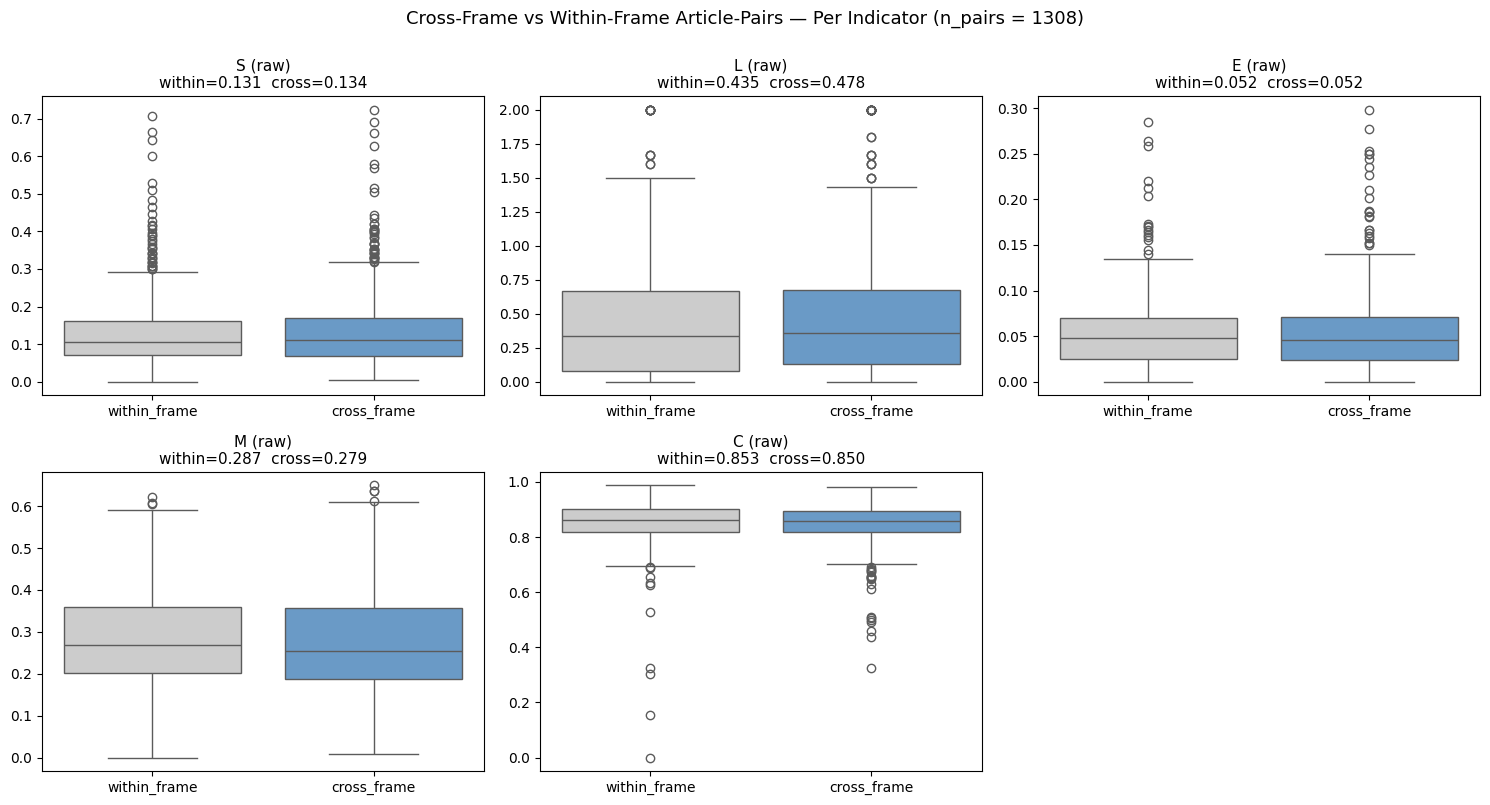

In [48]:
# visual: cross-frame vs within-frame, per indicator (no composite)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = [f'{c}_raw' for c in COMPONENTS]
labels  = [f'{c} (raw)' for c in COMPONENTS]

for ax, metric, label in zip(axes.flat[:5], metrics, labels):
    sns.boxplot(data=pairs, x='pair_type', y=metric, ax=ax,
                order=['within_frame', 'cross_frame'],
                palette={'within_frame': '#cccccc', 'cross_frame': '#5b9bd5'})
    means = pairs.groupby('pair_type')[metric].mean()
    ax.set_title(f'{label}\nwithin={means.get("within_frame", float("nan")):.3f}  '
                 f'cross={means.get("cross_frame", float("nan")):.3f}', size=11)
    ax.set_xlabel('')
    ax.set_ylabel('')

# hide the unused 6th axis
axes.flat[5].axis('off')

fig.suptitle('Cross-Frame vs Within-Frame Article-Pairs — Per Indicator '
             f'(n_pairs = {len(pairs)})', size=13, y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_fdi_validation.png'), dpi=150,
            bbox_inches='tight')
plt.show()


## Validation 2: ICC and Design-Adjusted Effective n

Compute the intra-class correlation per component (proportion of variance
explained by event-level grouping) and use it to derive a design-adjusted
effective sample size:

$$\text{DEFF} = 1 + (\bar m - 1) \cdot \text{ICC},\quad
n_{\text{eff}} = n_{\text{pairs}} / \text{DEFF}$$

where $\bar m$ is the average number of article-pairs per event. This
gives a defensible number to cite in the methodology section instead of
the raw n_pairs.

In [49]:
mean_pairs_per_event = pairs.groupby('event_id').size().mean()

def compute_icc(df, dv, group_col):
    """Compute ICC(1,1) via one-way ANOVA variance decomposition.

    ICC(1,1) = (MS_between - MS_within) / (MS_between + (n_bar - 1) * MS_within)

    Equivalent in expectation to a random-intercept null mixed model, but
    computed manually for transparency and to avoid version-dependent
    statsmodels internals (cov_re scaling, REML/ML conventions).
    """
    sub = df.dropna(subset=[dv]).copy()
    if sub[group_col].nunique() < 2:
        return None
    grand_mean = sub[dv].mean()
    g = sub.groupby(group_col)[dv].agg(['mean', 'count', 'var'])
    n_groups, n_total = len(g), len(sub)

    ss_between = (g['count'] * (g['mean'] - grand_mean) ** 2).sum()
    ss_within  = ((g['count'] - 1) * g['var'].fillna(0)).sum()
    df_between = n_groups - 1
    df_within  = n_total - n_groups
    ms_between = ss_between / df_between if df_between > 0 else 0
    ms_within  = ss_within  / df_within  if df_within  > 0 else 0
    n_bar      = g['count'].mean()

    denom = ms_between + (n_bar - 1) * ms_within
    icc = max(0.0, (ms_between - ms_within) / denom) if denom > 0 else 0.0
    var_event    = max(0.0, (ms_between - ms_within) / n_bar)
    var_residual = ms_within
    return {'var_event': var_event, 'var_residual': var_residual,
            'ICC': icc, 'n_pairs': n_total}

icc_rows = []
for c in COMPONENTS:
    dv = f'{c}_raw'
    r = compute_icc(pairs, dv, 'event_id')
    if r is None:
        icc_rows.append({'component': c, 'error': 'insufficient groups'}); continue
    deff  = 1 + (mean_pairs_per_event - 1) * r['ICC']
    n_eff = r['n_pairs'] / deff
    icc_rows.append({'component': c, 'n_pairs': r['n_pairs'],
                     'var_event': r['var_event'], 'var_residual': r['var_residual'],
                     'ICC': r['ICC'], 'DEFF': deff, 'n_eff': n_eff})

icc_df = pd.DataFrame(icc_rows)
print('Intra-class correlation (ICC) and design-adjusted effective n per component:')
print('(One-way ANOVA variance decomposition; chosen for transparency and reviewer auditability.)')
print()
print(icc_df.round(3).to_string(index=False))

icc_df.to_csv(os.path.join(OUTPUT_DIR, 'fdi_icc_per_component.csv'), index=False)
print('\nsaved fdi_icc_per_component.csv')
print(f'\nReport in methodology: ICC range = '
      f'[{icc_df["ICC"].min():.2f}, {icc_df["ICC"].max():.2f}]; '
      f'effective n per component is approximately '
      f'{icc_df["n_eff"].min():.0f}{chr(0x2013)}{icc_df["n_eff"].max():.0f}.')


Intra-class correlation (ICC) and design-adjusted effective n per component:
(One-way ANOVA variance decomposition; chosen for transparency and reviewer auditability.)

component  n_pairs  var_event  var_residual   ICC   DEFF   n_eff
        S     1308      0.003         0.007 0.313 21.189  61.732
        L     1308      0.030         0.165 0.152 10.773 121.416
        E     1308      0.000         0.001 0.191 13.283  98.475
        M     1308      0.006         0.008 0.414 27.676  47.261
        C     1308      0.002         0.004 0.259 17.668  74.033

saved fdi_icc_per_component.csv

Report in methodology: ICC range = [0.15, 0.41]; effective n per component is approximately 47–121.


## Discriminant Validity: Component Independence (Pearson r)

Correlations between the five raw components at the article-pair level
test whether the indicators carry distinct information. In a profile-
based metric, low-to-moderate cross-component correlations are a
discriminant-validity result: the indicators measure conceptually
different aspects of framing divergence rather than redundant signals.
Substantially correlated components would suggest the profile has
redundant dimensions and could be simplified.

Component correlation matrix (Pearson r):
       S_raw  L_raw  E_raw  M_raw  C_raw
S_raw  1.000  0.118  0.061  0.386  0.247
L_raw  0.118  1.000  0.034  0.073  0.101
E_raw  0.061  0.034  1.000  0.164  0.173
M_raw  0.386  0.073  0.164  1.000  0.508
C_raw  0.247  0.101  0.173  0.508  1.000


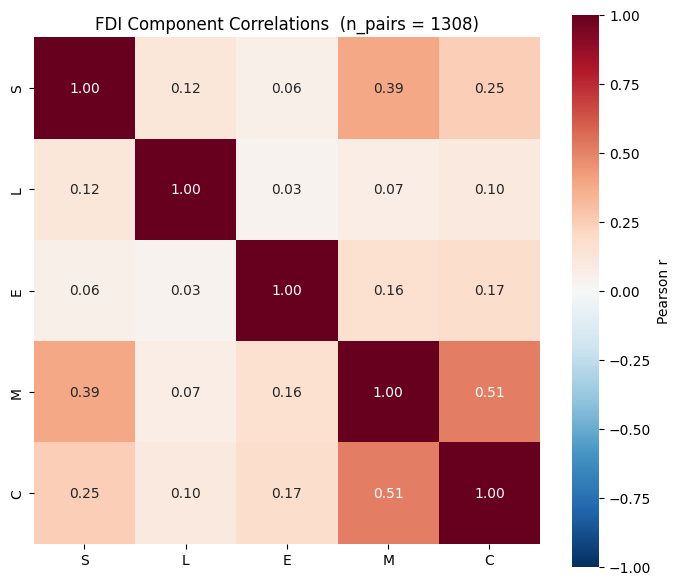


saved fdi_component_correlations.csv

Note: with strong event-level clustering (see ICC table), p-values
on these correlations should be cluster-adjusted before reporting.


In [50]:
raw_cols = [f'{c}_raw' for c in COMPONENTS]
corr = pairs[raw_cols].corr(method='pearson')
print('Component correlation matrix (Pearson r):')
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Pearson r'},
            xticklabels=COMPONENTS, yticklabels=COMPONENTS)
ax.set_title(f'FDI Component Correlations  (n_pairs = {len(pairs)})')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_fdi_component_correlations.png'),
            dpi=150)
plt.show()

corr.to_csv(os.path.join(OUTPUT_DIR, 'fdi_component_correlations.csv'))
print('\nsaved fdi_component_correlations.csv')

print('\nNote: with strong event-level clustering (see ICC table), p-values')
print('on these correlations should be cluster-adjusted before reporting.')


## Event-Level Aggregates (for Inferential Claims)

For inferential claims at the topic level (RQ3), aggregate article-pairs
back to event level (n = 20) by taking the mean of each indicator within
each event. This side-steps the clustering problem cleanly. Each
indicator is reported and plotted separately; there is no composite.

20 events in event-level table

Mean component scores by topic (event-level, n=20):
                    S_raw  L_raw  E_raw  M_raw  C_raw
topic                                                
environment         0.166  0.496  0.062  0.337  0.890
immigration         0.128  0.394  0.042  0.243  0.828
political conflict  0.095  0.449  0.052  0.259  0.836


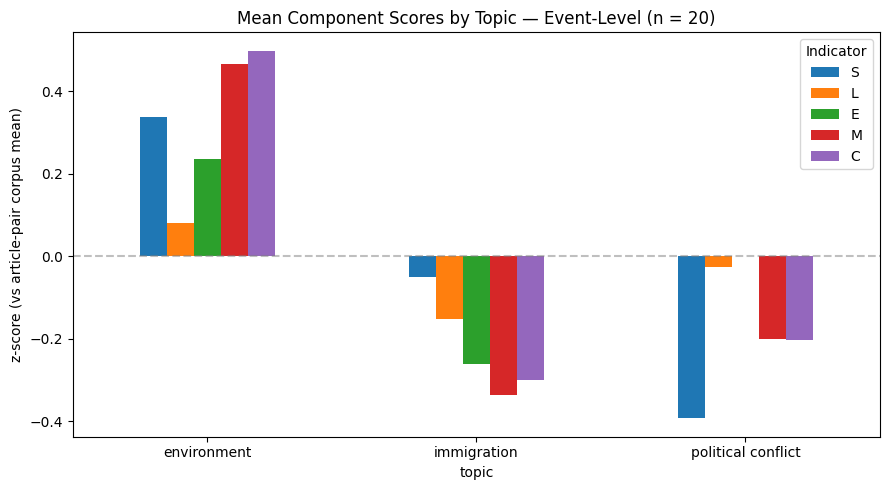

In [51]:
events = (pairs.groupby('event_id')
           .agg({**{f'{c}_raw': 'mean' for c in COMPONENTS},
                 **{f'{c}_z':   'mean' for c in COMPONENTS},
                 'topic': 'first',
                 'is_cross_frame': 'mean'})
           .rename(columns={'is_cross_frame': 'pct_cross_frame'})
           .reset_index())

print(f'{len(events)} events in event-level table')
print()
print('Mean component scores by topic (event-level, n=20):')
topic_stats = events.groupby('topic')[raw_cols].mean().round(3)
print(topic_stats.to_string())

# topic-level component profile (z-normalised, for cross-component comparison)
fig, ax = plt.subplots(figsize=(9, 5))
topic_z = events.groupby('topic')[[f'{c}_z' for c in COMPONENTS]].mean()
topic_z.columns = COMPONENTS
topic_z.plot(kind='bar', ax=ax)
ax.set_title(f'Mean Component Scores by Topic — Event-Level (n = {len(events)})')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('z-score (vs article-pair corpus mean)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Indicator', loc='best')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_components_by_topic.png'), dpi=150)
plt.show()


## Exemplar Profiles for the Thesis

Three article-pair exemplars chosen for **profile diversity** - one where
each of C, E, L dominates over the other components. Filtered to
**cross-frame pairs only** (within-frame pairs are the baseline, not the
showcase). Each exemplar is genuinely "Outlet A (frame X) vs
Outlet B (frame Y)" - the user-facing comparison the metric is designed
for. The radar profile is the centrepiece of the user-facing diagnostic
since the composite is no longer reported.

In [52]:
LABEL_MAP = {
    'S': 'sentiment tone',
    'L': 'word choice (loaded vocabulary)',
    'E': 'entity portrayal',
    'M': 'underlying content',
    'C': 'content selection',
}

cf = pairs[pairs['pair_type'] == 'cross_frame'].copy()

def dominant_pair_idx(comp, exclude=None):
    """Article-pair where component `comp` most exceeds the mean of the other
    components (in z-units). Skips indices already chosen for another archetype
    so the three exemplars are guaranteed distinct.
    """
    others = [c for c in COMPONENTS if c != comp]
    sub = cf.dropna(subset=[f'{comp}_z'] + [f'{c}_z' for c in others])
    if exclude:
        sub = sub.drop(index=[i for i in exclude if i in sub.index])
    score = sub[f'{comp}_z'] - sub[[f'{c}_z' for c in others]].mean(axis=1)
    return sub.loc[score.idxmax()].name

idx, chosen = {}, []
for comp in ['C', 'E', 'L']:
    pick = dominant_pair_idx(comp, exclude=chosen)
    idx[comp] = pick
    chosen.append(pick)

exemplars = pairs.loc[list(idx.values())].copy()
exemplars['archetype'] = ['Selection-dominant', 'Entity-dominant', 'Lexical-dominant']

def format_summary(row):
    components = {LABEL_MAP[c]: row.get(f'{c}_z', np.nan) for c in COMPONENTS}
    valid = {k: v for k, v in components.items() if pd.notna(v)}
    if len(valid) < 2:
        return '(insufficient component data)'
    sorted_c = sorted(valid.items(), key=lambda kv: -kv[1])
    return (f'Differs most on {sorted_c[0][0]} and {sorted_c[1][0]}; '
            f'most similar on {sorted_c[-1][0]}.')

exemplars['summary'] = exemplars.apply(format_summary, axis=1)

print('EXEMPLAR ARTICLE-PAIRS (cross-frame, one per dominant component)')
print('=' * 80)
for _, row in exemplars.iterrows():
    print(f"\n[{row['archetype']}]  event {row['event_id']}  ({row['topic']})")
    print(f"  {row['outlet_1']} ({row['frame_1']})  vs  "
          f"{row['outlet_2']} ({row['frame_2']})")
    print(f"  S={row['S_raw']:.3f}  L={row['L_raw']:.3f}  "
          f"E={row['E_raw']:.3f}  M={row['M_raw']:.3f}  C={row['C_raw']:.3f}")
    print(f"  --> {row['summary']}")


EXEMPLAR ARTICLE-PAIRS (cross-frame, one per dominant component)

[Selection-dominant]  event env_005  (environment)
  The Guardian (concern)  vs  News24 (neutral)
  S=0.058  L=0.714  E=0.000  M=0.369  C=0.973
  --> Differs most on content selection and underlying content; most similar on entity portrayal.

[Entity-dominant]  event imm_002  (immigration)
  South China Morning Post (humanitarian)  vs  BBC (neutral)
  S=0.127  L=0.057  E=0.278  M=0.415  C=0.819
  --> Differs most on entity portrayal and underlying content; most similar on word choice (loaded vocabulary).

[Lexical-dominant]  event env_002  (environment)
  BBC (neutral)  vs  Reuters (concern)
  S=0.006  L=2.000  E=0.011  M=0.258  C=0.879
  --> Differs most on word choice (loaded vocabulary) and content selection; most similar on sentiment tone.


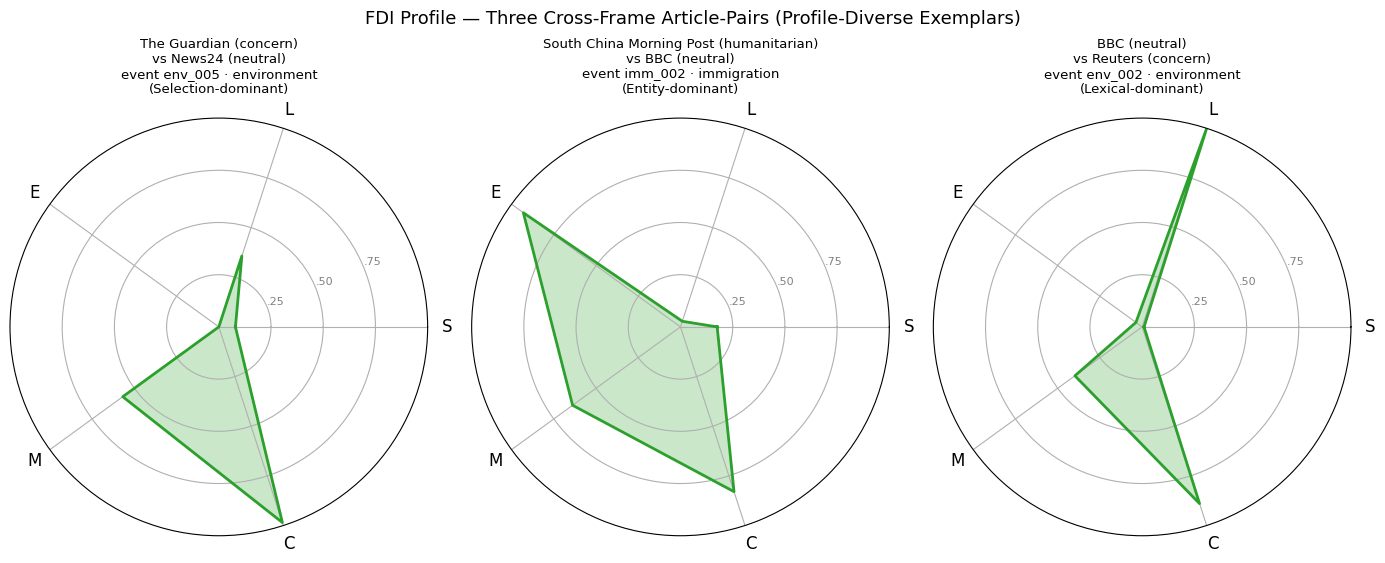

In [53]:
# min-max scale within the article-pair corpus for a 0-1 visual range
scaled = pairs[raw_cols].copy()
for col in raw_cols:
    lo, hi = scaled[col].min(), scaled[col].max()
    scaled[col] = (scaled[col] - lo) / (hi - lo) if hi > lo else 0
scaled.columns = [f'{c}_01' for c in COMPONENTS]
pairs_scaled = pd.concat([pairs.reset_index(drop=True),
                          scaled.reset_index(drop=True)], axis=1)

angles = [n / len(COMPONENTS) * 2 * pi for n in range(len(COMPONENTS))] + [0]

def compact_title(row, archetype):
    return (f"{row['outlet_1']} ({row['frame_1']})\n"
            f"vs {row['outlet_2']} ({row['frame_2']})\n"
            f"event {row['event_id']} · {row['topic']}\n"
            f"({archetype})")

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), subplot_kw=dict(polar=True))
for ax, (_, row), arch in zip(axes,
                              exemplars.iterrows(),
                              exemplars['archetype']):
    pair_row = pairs_scaled.loc[row.name]
    vals = [pair_row[f'{c}_01'] for c in COMPONENTS] + [pair_row[f'{COMPONENTS[0]}_01']]
    ax.plot(angles, vals, linewidth=2, color='C2')
    ax.fill(angles, vals, alpha=0.25, color='C2')
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(COMPONENTS, size=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['.25', '.50', '.75'], size=8, color='gray')
    ax.set_title(compact_title(row, arch), size=9.5, pad=18)

fig.suptitle('FDI Profile — Three Cross-Frame Article-Pairs '
             '(Profile-Diverse Exemplars)', y=1.04, size=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'plot_fdi_exemplar_radar.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## Save Outputs

In [54]:
# columns to drop from the saved CSVs (the composite is no longer reported).
# keep raw and z columns for every component plus all metadata.
keep_pair_cols = [
    'event_id', 'topic', 'article_id_1', 'article_id_2',
    'outlet_1', 'outlet_2', 'frame_1', 'frame_2',
    'pair_type', 'is_cross_frame',
    'S_raw', 'L_raw', 'E_raw', 'M_raw', 'C_raw',
    'S_z',   'L_z',   'E_z',   'M_z',   'C_z',
    'E_n_shared',
]
keep_pair_cols = [c for c in keep_pair_cols if c in pairs.columns]

keep_event_cols = (['event_id', 'topic', 'pct_cross_frame']
                   + [f'{c}_raw' for c in COMPONENTS]
                   + [f'{c}_z'   for c in COMPONENTS])
keep_event_cols = [c for c in keep_event_cols if c in events.columns]

pairs_out_path  = os.path.join(OUTPUT_DIR, 'results_fdi_pairs.csv')
events_out_path = os.path.join(OUTPUT_DIR, 'results_fdi_events.csv')

pairs[keep_pair_cols].to_csv(pairs_out_path, index=False)
events[keep_event_cols].to_csv(events_out_path, index=False)

print(f'  saved {pairs_out_path}  ({len(pairs)} article-pairs)')
print(f'  saved {events_out_path}  ({len(events)} events)')

print('\n' + '=' * 70)
print('FDI (profile-based) pipeline complete.')
print('=' * 70)
print('\nKey artefacts:')
for fn in ['results_fdi_pairs.csv', 'results_fdi_events.csv',
           'fdi_validation_crossframe.csv', 'fdi_icc_per_component.csv',
           'fdi_component_correlations.csv',
           'plot_fdi_validation.png', 'plot_fdi_component_correlations.png',
           'plot_components_by_topic.png', 'plot_fdi_exemplar_radar.png']:
    p = os.path.join(OUTPUT_DIR, fn)
    if os.path.exists(p):
        print(f'  {fn}')


  saved ./results_fdi_pairs.csv  (1308 article-pairs)
  saved ./results_fdi_events.csv  (20 events)

FDI (profile-based) pipeline complete.

Key artefacts:
  results_fdi_pairs.csv
  results_fdi_events.csv
  fdi_validation_crossframe.csv
  fdi_icc_per_component.csv
  fdi_component_correlations.csv
  plot_fdi_validation.png
  plot_fdi_component_correlations.png
  plot_components_by_topic.png
  plot_fdi_exemplar_radar.png


## What's Next

With per-indicator validation, ICC, discriminant-validity correlations,
and exemplar radar profiles in place, the natural next analyses are:

1. **Face-validity human alignment study.** Sample ~25 cross-frame
   article-pairs stratified across topics and dominant components.
   Recruit 2-3 raters and, for each pair, ask: "In what way(s) do
   these two articles differ in how they frame the event?" Compare the
   rater's top-ranked dimension with the dominant component identified by
   the FDI profile. Report agreement rate against a 20% chance baseline
   and inter-rater Cohen's κ. For a profile-based interpretive
   metric this is the most compelling validation move.

2. **AllSides external convergent validation.** Pull AllSides
   political-lean ratings for the 23 outlets, compute the absolute lean
   gap per article-pair, and correlate with each indicator separately
   using mixed-effects models with `event_id` as the grouping variable.
   The richer story than a single correlation is *which* indicators
   should track AllSides (L and E plausibly do; M and C plausibly do
   not) and whether that pattern holds.

3. **Mitigation overlay.** For the articles already neutralised by
   GPT-4o / GPT-5 / Gemini, recompute the indicators on neutralised
   article-pairs and compare per-component reductions. Connects RQ4 to
   the existing mitigation results.

4. **Fact-set upgrade for C.** Replace the entity-set Jaccard with a
   fact-set Jaccard via a single GPT-4o pass. Note this in the
   limitations section even if not implemented; it is a clear
   future-work item.

## Methodology paragraph (paste-ready)

> *FDI is computed at the article-pair level and reported as a five-
> indicator profile rather than a composite score. The decision to drop
> the composite follows established measurement-theory positions:
> Ravallion (2012a, 2012b) critiques composite indices on the grounds
> that equal-weight aggregation imposes an implicit and difficult-to-
> defend trade-off between dimensions and obscures component-level
> patterns; Stiglitz, Sen and Fitoussi (2009) and Stiglitz, Fitoussi and
> Durand (2018) recommend a dashboard of indicators over a single
> composite for well-being measurement; and the OECD/JRC (2008) handbook
> explicitly recognises that non-compensatory reporting may be
> preferable when components measure conceptually distinct dimensions.
> The argument has direct purchase in our domain: Czarnowska, Vyas and
> Shah (2021) show that NLP fairness metrics differ systematically in
> what facets of bias they capture, and Haider et al. (2025) argue
> media bias measurement should resist reduction to one or two
> dimensions.*
>
> *We retain both cross-frame and within-frame article-pairs: the latter
> serve as a baseline against which cross-frame divergence is benchmarked
> per indicator, providing built-in construct validation. Article-pairs
> nested within the same event are not statistically independent
> (ICC range = [X, Y]); we therefore report descriptive statistics at
> the article-pair level using design-adjusted effective sample sizes
> (n_eff range = [Z1, Z2]) and use event-level aggregates (n = 20) with
> mixed-effects modelling for inferential claims. Face validity is
> assessed via a separate human alignment study comparing the FDI
> profile's dominant component against human raters' descriptions of
> divergence for a sample of cross-frame article-pairs.*